# Exploración Visual de los Datos – Subtes de Buenos Aires

El objetivo principal es explorar los datasets del sistema de Subtes de Buenos Aires
para comprender su estructura, distribución y patrones iniciales de demanda.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/historico_2019.csv")

# Chequeo basico y general de los datos
df.head() # primeras 5 filas
df.info()
df.describe() # estadisticas descriptivas del dataframe
df.isnull().sum() # verifico si hay nulos en las columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12662343 entries, 0 to 12662342
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   periodo          int64  
 1   fecha            object 
 2   desde            object 
 3   hasta            object 
 4   linea            object 
 5   molinete         object 
 6   estacion         object 
 7   pax_pagos        float64
 8   pax_pases_pagos  float64
 9   pax_franq        float64
 10  total            float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1.0+ GB


periodo            0
fecha              0
desde              0
hasta              0
linea              0
molinete           0
estacion           0
pax_pagos          0
pax_pases_pagos    0
pax_franq          0
total              0
dtype: int64

In [7]:
df.head(10)

,periodo,fecha,desde,hasta,linea,molinete,estacion,pax_pagos,pax_pases_pagos,pax_franq,total
0,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Lima_N_Turn02,Lima,1.0,0.0,0.0,1.0
1,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Loria_N_Turn03,Loria,3.0,0.0,0.0,3.0
2,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_Q_HALL_Turn01,Plaza Miserere,3.0,0.0,0.0,3.0
3,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_S_Turn01,Plaza Miserere,6.0,0.0,0.0,6.0
4,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Miserere_S_Turn03,Plaza Miserere,10.0,0.0,0.0,10.0
5,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Peru_S_Turn03,Peru,2.0,0.0,0.0,2.0
6,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_PJunta_S_Turn04,Primera Junta,9.0,0.0,0.0,9.0
7,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_SanPedrito_Oeste_Turn05,San Pedrito,2.0,0.0,1.0,3.0
8,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_SnzPena_N_Turn01,Saenz PeÃÂ±a,1.0,0.0,0.0,1.0
9,201901,2019-01-01,08:00:00,08:15:00,LineaA,LineaA_Acoyte_N_Turn01,Acoyte,1.0,0.0,0.0,1.0


## Observaciones iniciales

El dataset tiene más de 12,6 millones de registros y 11 variables,
lo que indica un alto nivel de granularidad en la información, con datos a nivel
de molinete, estación, línea y franja horaria.

No se detectaron valores nulos en ninguna de las columnas, lo que sugiere una buena
calidad de los datos en términos de completitud. Las variables disponibles permiten
analizar la demanda de pasajeros de manera detallada, diferenciando entre pasajeros
pagos, pases pagos y viajes franquiciados.

Noté variables temporales (`fecha`, `desde`, `hasta`) que requerirán
transformaciones de tipo para facilitar análisis posteriores, así como variables
geográficas y operativas (`linea`, `estacion`, `molinete`) que permitirán estudiar
patrones de uso y congestión del sistema.


# Entender que mide la variable "total"

In [4]:
df["total"].describe()

count    1.266234e+07
mean     2.695714e+01
std      2.939805e+01
min      0.000000e+00
25%      6.000000e+00
50%      1.700000e+01
75%      3.800000e+01
max      1.245900e+04
Name: total, dtype: float64

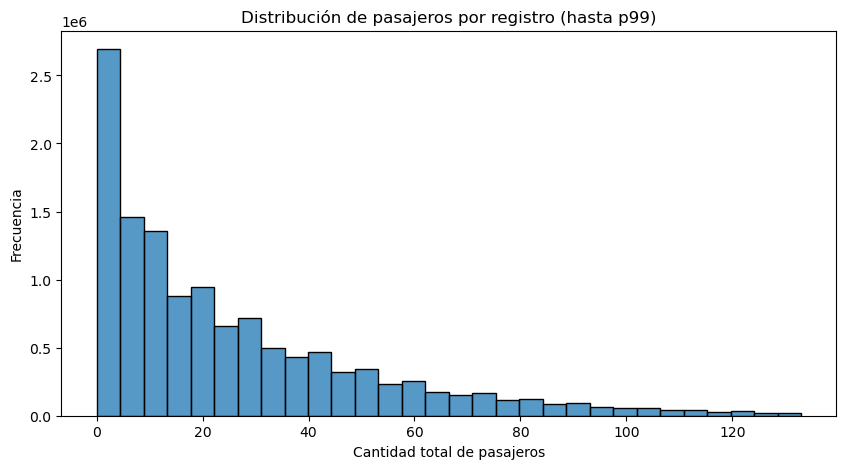

p99: 133.0


In [9]:
p99 = df["total"].quantile(0.99)

plt.figure(figsize=(10,5))
sns.histplot(df.loc[df["total"] <= p99, "total"], bins=30)
plt.title("Distribución de pasajeros por registro (hasta p99)")
plt.xlabel("Cantidad total de pasajeros")
plt.ylabel("Frecuencia")
plt.show()

print("p99:", p99)
